<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🔍 Análisis Exploratorio de Datos (EDA)</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 3 — El primer paso antes de entrenar cualquier modelo</p>
</div>

El **Análisis Exploratorio de Datos** (*Exploratory Data Analysis*, EDA) es el proceso de examinar un conjunto de datos antes de modelarlo: conocer su tamaño, sus tipos de datos, si tiene valores faltantes, cómo se distribuyen sus variables y cómo se relacionan entre sí. Omitir este paso es una de las causas más comunes de que un modelo de Machine Learning falle o dé resultados poco confiables.

En esta guía se aplican las técnicas más comunes de EDA sobre el conjunto de datos **Iris**, un clásico del aprendizaje automático que contiene 150 flores de 3 especies distintas, medidas según el largo y ancho de sus sépalos y pétalos.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#importacion">Importación de librerías</a></li>
<li><a href="#cargar-datasets">Cargar datasets</a></li>
<li><a href="#verificacion-inicial">Verificación inicial: dimensiones, tipos y valores nulos</a></li>
<li><a href="#estadistica-descriptiva">Estadística descriptiva</a></li>
<li><a href="#visualizacion">Visualización de datos</a></li>
<li><a href="#correlacion">Correlación de variables</a></li>
<li><a href="#mapa-calor">Matriz de correlación con Seaborn</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="importacion"></a>

## <span style="color:#F97066;">1.</span> Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

<a id="cargar-datasets"></a>

## <span style="color:#F97066;">2.</span> Cargar datasets

Se utilizará el conjunto de datos **Iris**, incluido directamente en `scikit-learn`. Contiene 150 registros con 4 características numéricas (largo y ancho de sépalo y pétalo, en centímetros) y una columna `species` que indica a cuál de las 3 especies de flor pertenece cada registro (codificada como 0, 1 o 2).

In [2]:
# Cargar dataset de Iris en DataFrame
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = iris.target  # Agregar la columna de etiquetas de clase 

In [3]:
# iris
# iris.data 
# iris.target
# iris.feature_names
df_iris 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


<a id="verificacion-inicial"></a>

## <span style="color:#F97066;">3.</span> Verificación inicial: dimensiones, tipos y valores nulos

Antes de calcular cualquier estadística, conviene responder tres preguntas básicas: ¿cuántos registros y columnas tiene el conjunto de datos?, ¿qué tipo de dato tiene cada columna?, y ¿hay valores faltantes que deban tratarse? El método `.info()` de pandas responde las dos primeras; `.isnull().sum()` responde la tercera.

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Ejecute la siguiente celda y confirme que las 5 columnas son numéricas y que no hay valores nulos.

In [4]:
# Dimensiones del dataset (filas, columnas)
print(f"Dimensiones: {df_iris.shape}")

# Tipos de datos y conteo de valores no nulos por columna
df_iris.info()

Dimensiones: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
# Conteo explícito de valores nulos por columna
df_iris.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

También conviene verificar el **balance de clases**: si una especie estuviera muy sobrerrepresentada respecto a las demás, cualquier modelo de clasificación entrenado con estos datos podría aprender a favorecer la clase mayoritaria.

In [6]:
# Verificar que las clases estén balanceadas
df_iris['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

<a id="estadistica-descriptiva"></a>

## <span style="color:#F97066;">4.</span> Estadística descriptiva

El método `.describe()` de pandas resume cada columna numérica con estadísticos clave: `count` (cantidad de valores), `mean` y `std` (promedio y desviación estándar), y los cuartiles `min`, `25%`, `50%` (mediana), `75%` y `max`. Es una forma rápida de detectar rangos inusuales, asimetrías o posibles outliers.

In [7]:
# Resumen Estadístico
print("Resumen Estadístico:")
df_iris.describe()

Resumen Estadístico:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


<a id="visualizacion"></a>

## <span style="color:#F97066;">5.</span> Visualización de datos

Un **histograma** muestra cómo se distribuyen los valores de una variable (por ejemplo, si siguen una forma de campana o están sesgados), mientras que un **boxplot** (diagrama de caja) resume esa misma distribución mediante cuartiles y facilita identificar valores atípicos (*outliers*) como puntos fuera de los "bigotes".

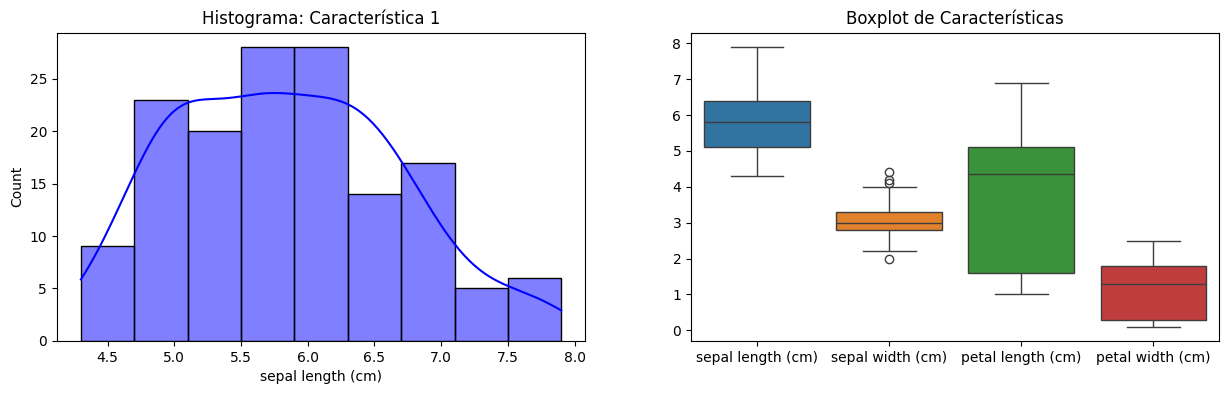

In [8]:
# Visualización de Datos
plt.figure(figsize=(15, 4))

# Histogramas
plt.subplot(1, 2, 1)
sns.histplot(df_iris.iloc[:, 0], kde=True, color="blue")
plt.title("Histograma: Característica 1")

# Boxplot para identificar outliers
plt.subplot(1, 2, 2)
sns.boxplot(data=df_iris.iloc[:, :-1])
plt.title("Boxplot de Características")

plt.show() 

### Relación entre variables por especie

Los gráficos anteriores muestran cada variable de forma aislada. Para explorar cómo se relacionan **todas las variables entre sí**, y si esas relaciones difieren por especie, `seaborn` ofrece `pairplot()`: genera una cuadrícula con un diagrama de dispersión para cada par de variables (y un histograma de densidad en la diagonal), coloreando los puntos según la columna indicada en `hue`.

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Ejecute la siguiente celda y observe cómo, en varios pares de variables (especialmente las relacionadas con el pétalo), las tres especies forman grupos claramente separables a simple vista.

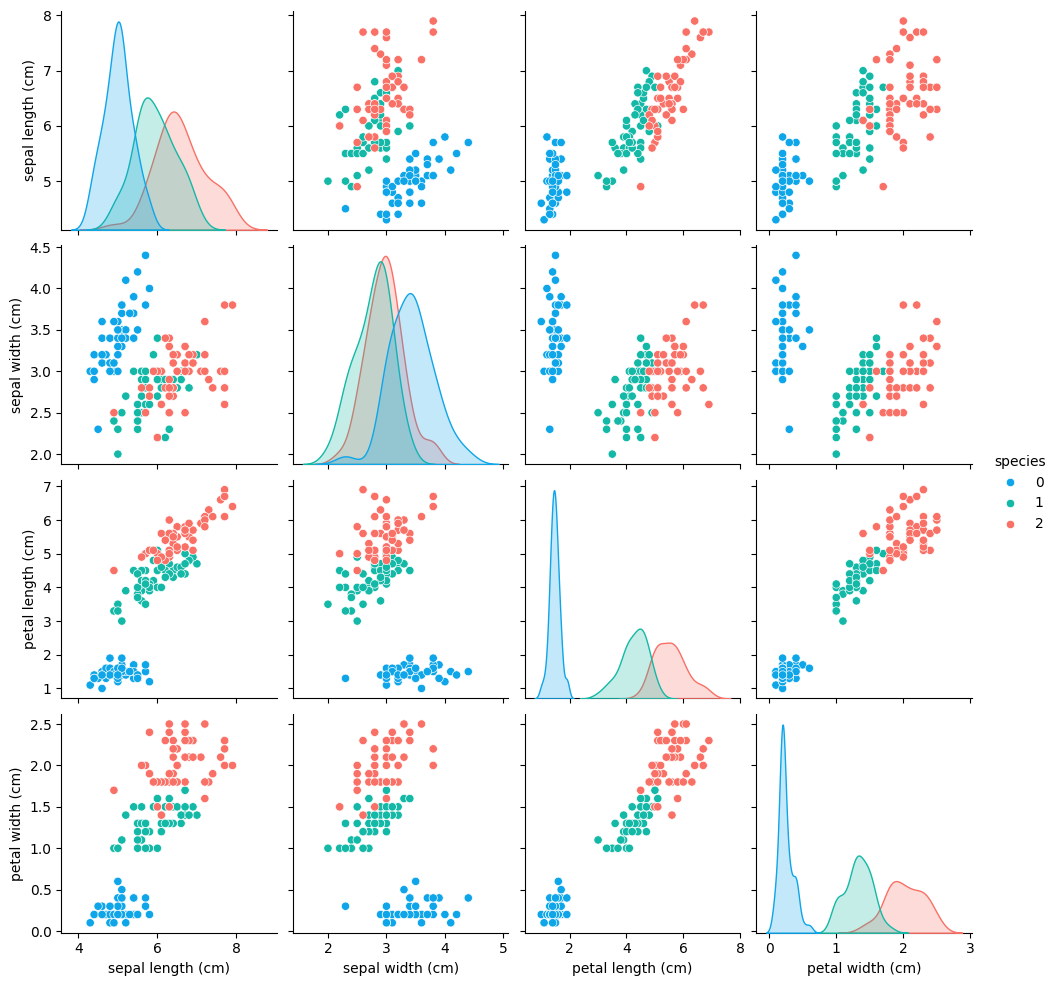

In [9]:
# Relación entre todas las variables numéricas, coloreada por especie
sns.pairplot(df_iris, hue="species", palette=["#0EA5E9", "#14B8A6", "#F97066"])
plt.show()

<a id="correlacion"></a>

## <span style="color:#F97066;">6.</span> Correlación de variables

El **coeficiente de correlación de Pearson** mide qué tan relacionadas están linealmente dos variables, en un rango de -1 a 1: valores cercanos a **1** indican una relación positiva fuerte (cuando una crece, la otra también), cercanos a **-1** indican una relación negativa fuerte (cuando una crece, la otra decrece), y cercanos a **0** indican poca o ninguna relación lineal.

In [10]:
# Matriz de Correlación
correlaciones = df_iris.corr()
correlaciones_df = pd.DataFrame(correlaciones)
print("Matriz de Correlación:")
display(correlaciones_df) 

Matriz de Correlación:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
species,0.782561,-0.426658,0.949035,0.956547,1.000000


<a id="mapa-calor"></a>

## <span style="color:#F97066;">7.</span> Matriz de correlación con `Seaborn`

Una tabla de correlaciones como la anterior es precisa, pero difícil de escanear visualmente cuando hay muchas variables. Un **mapa de calor** (*heatmap*) codifica cada valor de correlación como un color, permitiendo detectar de un vistazo qué pares de variables están más (o menos) relacionados.

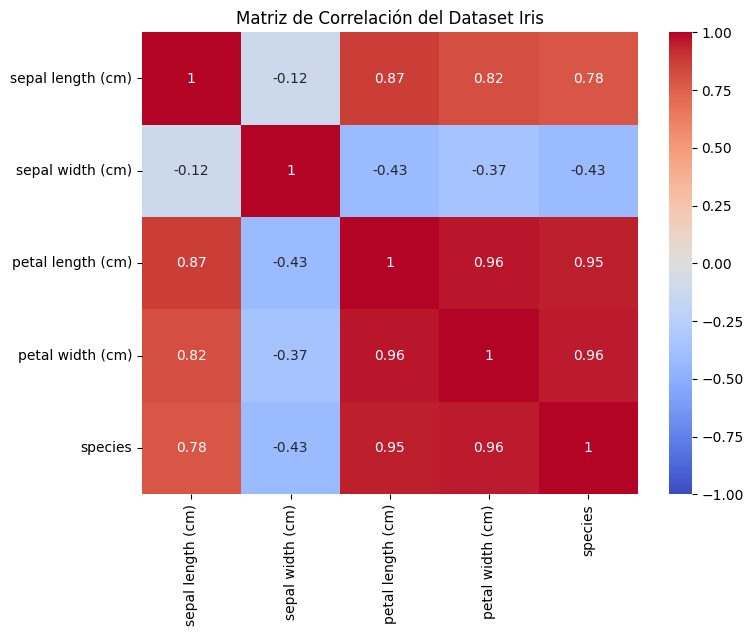

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Suponiendo que df_iris ya está definido y contiene los datos
correlaciones = df_iris.corr()

# Crear la figura y el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación del Dataset Iris')
plt.show()

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>
En este notebook se presentaron las técnicas más comunes de Análisis Exploratorio de Datos:

- Verificación inicial: dimensiones, tipos de datos, valores nulos y balance de clases.
- Estadística descriptiva con <code>.describe()</code>.
- Visualización de distribuciones (histograma, boxplot) y de relaciones entre variables (<code>pairplot</code>).
- Correlación entre variables, en tabla y como mapa de calor.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>5-data-preprocessing.ipynb</code> — una vez comprendidos los datos, el siguiente paso es prepararlos para entrenar un modelo.</li>
</ul>
</div>